# Task 2: Customer Segmentation using Unsupervised Learning

## Objective
The goal of this task is to segment customers into distinct groups based on their spending behavior using clustering techniques.

## Dataset
We are using the Mall Customers Dataset, which contains information about customer demographics and spending patterns.

## Step 1: Data Loading and Exploratory Data Analysis (EDA)

In this step, we will:
- Load the dataset
- Explore its structure
- Perform basic data analysis
- Visualize key features

In [7]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('Mall_Customers.csv', sep=',') # Changed separator to comma

# Display first rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Shape
print("Dataset Shape:", df.shape)

# Columns
print("\nColumns:")
print(df.columns.tolist())

# Info
print("\nDataset Info:")
df.info()

Dataset Shape: (200, 1)

Columns:
['CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 1 columns):
 #   Column                                                           Non-Null Count  Dtype 
---  ------                                                           --------------  ----- 
 0   CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)  200 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [4]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,"CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)"
count,200
unique,200
top,"1,Male,19,15,39"
freq,1


In [5]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)


Missing Values:
CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)    0
dtype: int64

Duplicate Rows: 0


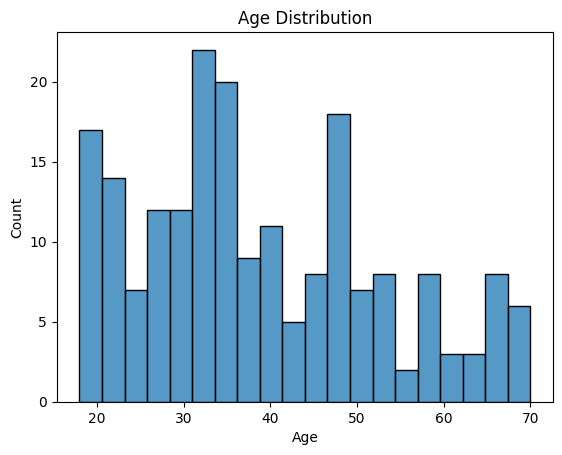

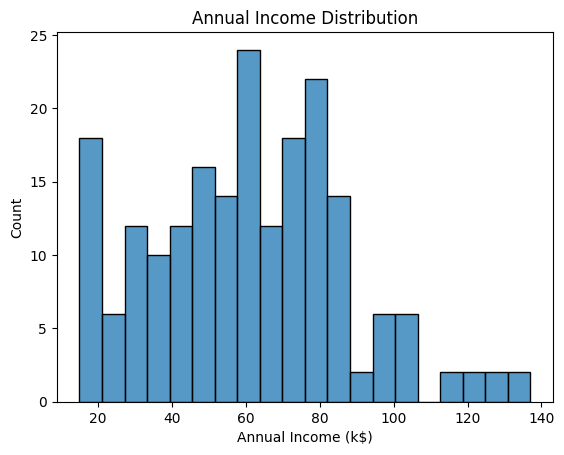

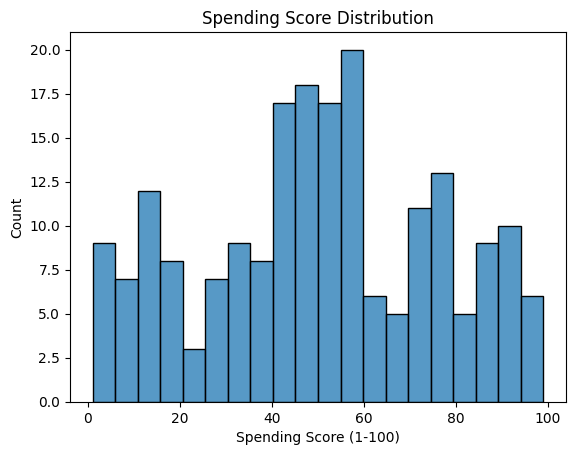

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
plt.figure()
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

# Income distribution
plt.figure()
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title("Annual Income Distribution")
plt.show()

# Spending score distribution
plt.figure()
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.show()

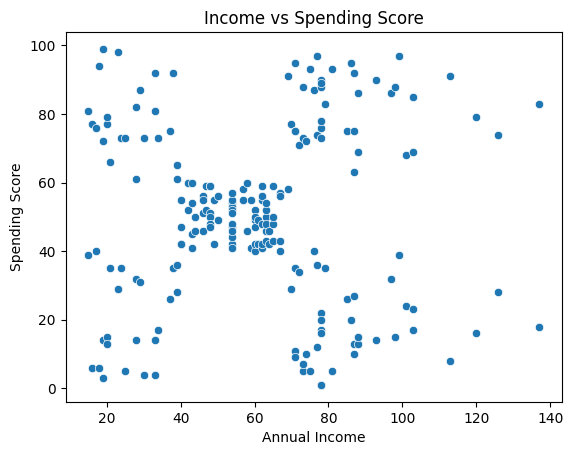

In [9]:
plt.figure()

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

## Conclusion (Step 1)

- The dataset contains customer demographic and spending information.
- No missing values or duplicates were found.
- Distributions of Age, Income, and Spending Score were analyzed.
- A visible relationship between income and spending score suggests potential customer segments.

Next, we will apply K-Means clustering to group customers.

## Step 2: K-Means Clustering and Elbow Method

In this step, we will:
- Select relevant features for clustering
- Apply the Elbow Method to determine the optimal number of clusters
- Train the K-Means clustering model

In [11]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Preview
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


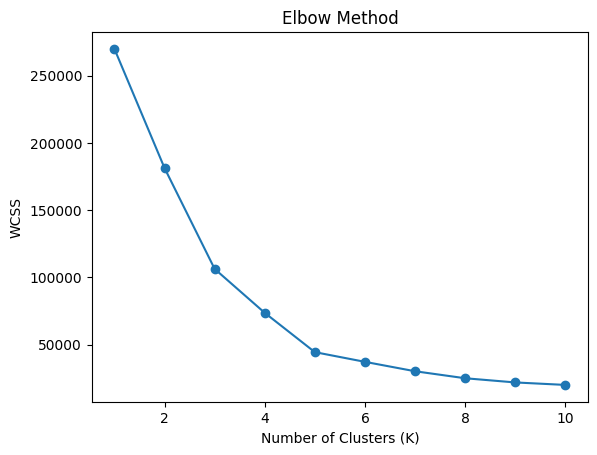

In [12]:
from sklearn.cluster import KMeans

wcss = []  # Within-Cluster Sum of Squares

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# Plot Elbow Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [13]:
# Train KMeans with optimal clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit model
df['Cluster'] = kmeans.fit_predict(X)

# View results
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [14]:
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


## Conclusion (Step 2)

- The Elbow Method was used to determine the optimal number of clusters.
- Based on the curve, K = 5 was selected as the optimal number.
- K-Means clustering was applied to segment customers into 5 distinct groups.

Next, we will visualize these clusters and interpret their meaning.

## Step 3: Cluster Visualization

In this step, we visualize the clusters formed by K-Means to better understand customer segmentation.

We will:
- Plot customer clusters using a scatter plot
- Highlight cluster centers
- Interpret different customer groups

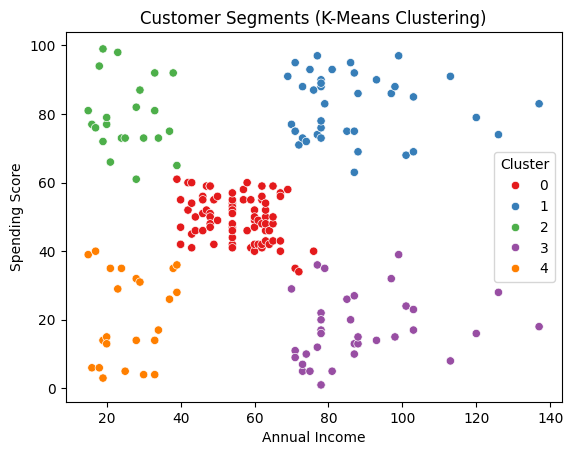

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

# Scatter plot with clusters
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.title("Customer Segments (K-Means Clustering)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend(title='Cluster')
plt.show()

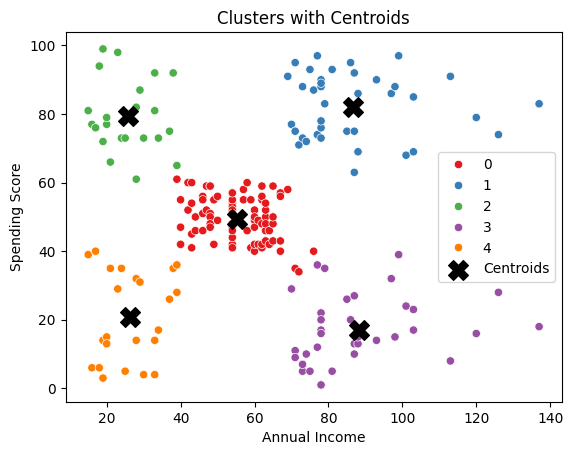

In [16]:
# Get cluster centers
centers = kmeans.cluster_centers_

plt.figure()

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1'
)

# Plot centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Clusters with Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend()
plt.show()

### Cluster Interpretation

- Cluster 0: Customers with high income and high spending behavior.
- Cluster 1: Customers with high income but low spending.
- Cluster 2: Customers with low income but high spending.
- Cluster 3: Customers with low income and low spending.
- Cluster 4: Customers with average income and moderate spending.

These clusters represent different customer segments that can be targeted with specific marketing strategies.

## Step 4: PCA (Principal Component Analysis) Visualization

In this step, we apply PCA to reduce the dataset into 2 dimensions for better visualization of clusters.

PCA helps:
- Reduce dimensionality
- Preserve important information
- Visualize clusters more clearly

In [17]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Convert to DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add cluster labels
df_pca['Cluster'] = df['Cluster']

df_pca.head()

,PC1,PC2,Cluster
0,-46.903574,1.099247,4
1,-35.924389,41.638826,2
2,-54.564848,-31.014689,4
3,-36.004798,37.516505,2
4,-44.711709,1.541657,4


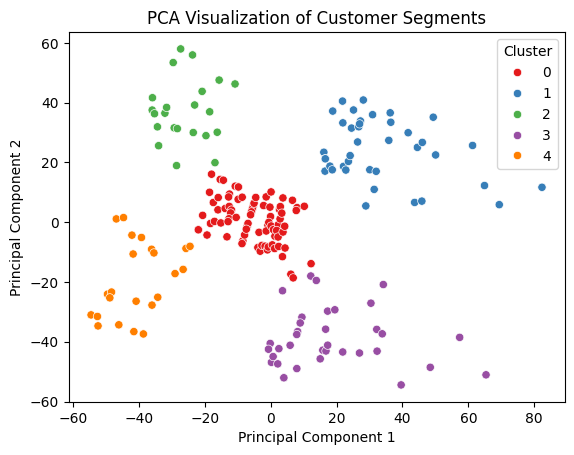

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='Set1'
)

plt.title("PCA Visualization of Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title='Cluster')
plt.show()

In [19]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.50981041 0.49018959]


### PCA Interpretation

- PCA reduced the dataset to 2 dimensions while preserving most of the variance.
- The clusters remain distinguishable even after dimensionality reduction.
- This confirms that the selected features effectively represent customer behavior.

## Conclusion (Step 4)

- PCA was successfully applied to reduce data dimensions.
- Clusters were visualized in a 2D space using principal components.
- The separation between clusters confirms meaningful segmentation.

Next, we will develop marketing strategies based on these clusters.

## Step 5: Marketing Strategy Based on Customer Segments

In this step, we analyze each cluster and propose targeted marketing strategies based on customer behavior.

Customer segmentation allows businesses to:
- Personalize marketing campaigns
- Improve customer engagement
- Increase sales and retention

In [21]:
# Group by cluster and calculate mean values
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


### Cluster Analysis

- Cluster 0: High income, high spending customers (Premium customers)
- Cluster 1: High income, low spending customers (Careful spenders)
- Cluster 2: Low income, high spending customers (Impulsive buyers)
- Cluster 3: Low income, low spending customers (Budget customers)
- Cluster 4: Moderate income and spending (Average customers)

### Marketing Strategies

- **Cluster 0 (High Income, High Spending)**  
  Strategy: Offer premium products, loyalty programs, and exclusive deals to retain these valuable customers.

- **Cluster 1 (High Income, Low Spending)**  
  Strategy: Target with personalized marketing campaigns and discounts to encourage spending.

- **Cluster 2 (Low Income, High Spending)**  
  Strategy: Provide attractive offers and promotions but monitor spending patterns to avoid over-targeting.

- **Cluster 3 (Low Income, Low Spending)**  
  Strategy: Focus on budget-friendly products and basic offers.

- **Cluster 4 (Average Customers)**  
  Strategy: Use general marketing campaigns and seasonal promotions to maintain engagement.

## Final Conclusion

- Customers were successfully segmented into distinct groups using K-Means clustering.
- The Elbow Method helped determine the optimal number of clusters.
- PCA was used to visualize clusters in reduced dimensions.
- Each cluster represents a unique customer behavior pattern.

By understanding these segments, businesses can design targeted marketing strategies to improve customer satisfaction and increase revenue.

This task demonstrates the practical application of unsupervised learning for customer segmentation and business decision-making.